# Trabalho 1 - Análise Descritiva e Visualização de Dados (Steam)
**Aluno(a):** Mateus Nunes Oliveira

## 2.1 Problema e perguntas

**Contexto do dataset:**
Neste trabalho utilizei o dataset ***steam_games_2026.csv*** (https://www.kaggle.com/datasets/waddahali/top-1000-steam-games-20242026/code), que contém informações sobre os 1.000 jogos cadastrados de maior sucesso recente na plataforma/loja Steam. O arquivo contém preço, desconto, gênero e engajamento do público (avaliações positivas, quantidade total de avaliações e estimativa de jogadores).

**Perguntas a serem respondidas:**
1. Como os preços dos jogos estão distribuídos na plataforma? Estão muito concentrados ou dispersos?
2. Qual é o perfil geral de aprovação dos jogos? Geralmente o público é mais positivo ou negativo?
3. Comparando os 5 gêneros principais, existem diferenças muito grandes nas medianas de preços e em suas variabilidades?
4. Existe alguma associação muito visível entre o preço de um jogo e sua aprovação pelos jogadores?

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#Dataset upado

url = "https://raw.githubusercontent.com/mateusnunes-data/Steam-Exploratory-Data-Analysis/main/steam_games_2026.csv"
df = pd.read_csv(url)

df.head()

,AppID,Name,Release_Date,Primary_Genre,All_Tags,Price_USD,Discount_Pct,Review_Score_Pct,Total_Reviews,Steam_Deck_Status,Estimated_Owners,24h_Peak_Players
0,730,Counter-Strike 2,2012-08-21,Action,FPS;Shooter;Multiplayer;Competitive;Action;Tea...,0.00,0,83,4980365,Unknown,149410950,1013936
1,2868840,Slay the Spire 2,2026-03-05,Indie,Strategy;Roguelike;Card Game;Deckbuilding;Co-o...,24.99,0,97,49549,Unknown,1486470,0
2,3321460,Crimson Desert,2026-03-19,Action,Action;Open World;Singleplayer;Adventure;Comba...,69.99,0,0,0,Unknown,0,0
3,3065800,Marathon,2026-03-05,Action,Extraction Shooter;PvP;Multiplayer;Sci-fi;Shoo...,39.99,0,90,24360,Unknown,730800,0
4,3764200,Resident Evil Requiem,2026-02-26,Action,Survival Horror;Zombies;Horror;Third-Person Sh...,69.99,0,96,79667,Unknown,2390010,0


## 2.2 Conhecimento dos dados

O primeiro passo é entender a estrutura da nossa base (tamanho, tipos de variáveis e dados faltantes).

In [11]:
print("\n--- Tipos de Variáveis e Nulos ---")
print(df.info())

print("\n--- Primeiras linhas ---")
display(df.head(3))


--- Tipos de Variáveis e Nulos ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   AppID              1000 non-null   int64  
 1   Name               1000 non-null   object 
 2   Release_Date       999 non-null    object 
 3   Primary_Genre      1000 non-null   object 
 4   All_Tags           986 non-null    object 
 5   Price_USD          1000 non-null   float64
 6   Discount_Pct       1000 non-null   int64  
 7   Review_Score_Pct   1000 non-null   int64  
 8   Total_Reviews      1000 non-null   int64  
 9   Steam_Deck_Status  1000 non-null   object 
 10  Estimated_Owners   1000 non-null   int64  
 11  24h_Peak_Players   1000 non-null   int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 93.9+ KB
None

--- Primeiras linhas ---


,AppID,Name,Release_Date,Primary_Genre,All_Tags,Price_USD,Discount_Pct,Review_Score_Pct,Total_Reviews,Steam_Deck_Status,Estimated_Owners,24h_Peak_Players
0,730,Counter-Strike 2,2012-08-21,Action,FPS;Shooter;Multiplayer;Competitive;Action;Tea...,0.00,0,83,4980365,Unknown,149410950,1013936
1,2868840,Slay the Spire 2,2026-03-05,Indie,Strategy;Roguelike;Card Game;Deckbuilding;Co-o...,24.99,0,97,49549,Unknown,1486470,0
2,3321460,Crimson Desert,2026-03-19,Action,Action;Open World;Singleplayer;Adventure;Comba...,69.99,0,0,0,Unknown,0,0


###Interpretação:
- O dataset possui 1.000 linhas (jogos) e 12 colunas (variáveis).
- Temos variáveis numéricas contínuas (Price_USD), numéricas discretas (Discount_Pct, Estimated_Owners, 24h_Peak_Players, etc.) e variáveis qualitativas nominais (Name, Primary_Genre).
- Analisando o df.info(), podemos ver que temos apenas uma célula vazia em release date e 14 em all tags. É um dataset quase perfeito para análise. Gostaria de continuar com ele por ser um tema do meu gosto pessoal e por crer que os dados faltantes não influenciarão muito no resultado da análise.

## 2.3 Estatística descritiva

Abaixo iremos analisar a média, mediana e moda, limites e dispersão das nossas duas principais variáveis numéricas contínuas/percentuais (Price_USD e Review_Score_Pct).

In [12]:
colunas_interesse = ['Price_USD', 'Review_Score_Pct']

#.describe().T para inverter as linhas e colunas
desc = df[colunas_interesse].describe().T

#Cálculos manuais de amplitude, variância, intervalo interquartil e coeficiente de variação.
desc['amplitude'] = desc['max'] - desc['min']
desc['variancia'] = df[colunas_interesse].var()
desc['IQR'] = desc['75%'] - desc['25%']
desc['CV (%)'] = (desc['std'] / desc['mean']) * 100

#Juntando tudo numa tabela fácil de ver
display(desc[['mean', '50%', 'min', 'max', 'amplitude', 'std', 'variancia', '25%', '75%', 'IQR', 'CV (%)']].round(2))

,mean,50%,min,max,amplitude,std,variancia,25%,75%,IQR,CV (%)
Price_USD,21.99,19.79,0.0,69.99,69.99,18.81,353.90,7.79,29.99,22.2,85.54
Review_Score_Pct,79.66,85.00,0.0,100.00,100.00,19.38,375.67,75.00,92.00,17.0,24.33


**Interpretação:**
* **Coluna Price_USD:** A média de preço é USD 21,99, enquanto a mediana (Q2 / 50%) é inferior, USD 19,79. Concluímos com isso que há uma distribuição assimétrica à direita (por conta dos jogos muito caros). O Coeficiente de Variação (CV) é de 85,54%, indicando uma dispersão altíssima em torno da média. O IQR nos mostra que 50% dos jogos centrais custam entre USD 7,79 e USD 29,99.
* **Coluna Review_Score_Pct:** Ao contrário do preço, a mediana das avaliações (85,00%) é superior à média (79,66%), o que indica uma forte assimetria à esquerda (a maioria dos jogos tem boas notas, mas alguns com notas péssimas puxam a média para baixo). O CV é de 24,33%, revelando que a aceitação do público é menos dispersa que os preços.

## 2.4 Distribuições

Utilizaremos histogramas e boxplots como trabalhamos em aula para visualizar o formato dessas distribuições, investigar a assimetria apontada na estatística descritiva e detectar possíveis outliers.

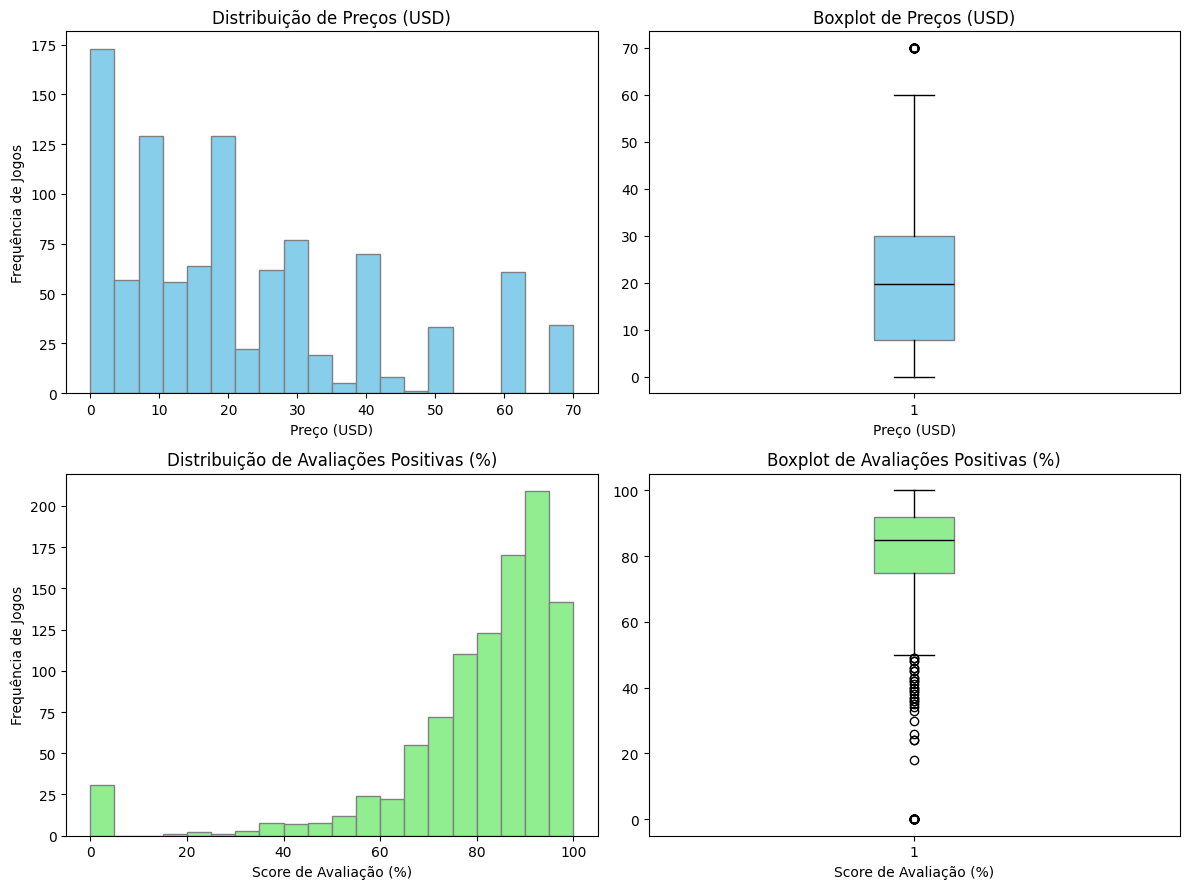

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

#Histograma dos Preços
axes[0,0].hist(df['Price_USD'], bins=20, color='skyblue', edgecolor='grey')
axes[0,0].set_title('Distribuição de Preços (USD)')
axes[0,0].set_xlabel('Preço (USD)')
axes[0,0].set_ylabel('Frequência de Jogos')

#Boxplot dos Preços
axes[0,1].boxplot(df['Price_USD'], patch_artist=True, boxprops=dict(facecolor='skyblue', color='grey'), medianprops=dict(color='black'))
axes[0,1].set_title('Boxplot de Preços (USD)')
axes[0,1].set_xlabel('Preço (USD)')

#Histograma das Avaliações
axes[1,0].hist(df['Review_Score_Pct'], bins=20, color='lightgreen', edgecolor='grey')
axes[1,0].set_title('Distribuição de Avaliações Positivas (%)')
axes[1,0].set_xlabel('Score de Avaliação (%)')
axes[1,0].set_ylabel('Frequência de Jogos')

#Boxplot das Avaliações
axes[1,1].boxplot(df['Review_Score_Pct'], patch_artist=True, boxprops=dict(facecolor='lightgreen', color='grey'), medianprops=dict(color='black'))
axes[1,1].set_title('Boxplot de Avaliações Positivas (%)')
axes[1,1].set_xlabel('Score de Avaliação (%)')

plt.tight_layout()
plt.show()

**Interpretação:**
- **Preço:** O histograma demonstra visualmente a assimetria à direita: o maior volume de jogos custa abaixo de 30 dólares. Observando o boxplot, os pontos isolados próximos e no valor máximo ($69,99) podem ser detectados como outliers. Na indústria dos jogos, esses costumam ser os lançamentos do tipo "AAA" (blockbusters como GTA, God of War, Resident Evil etc.).
- **Avaliação:** A distribuição tem longa cauda à esquerda. O boxplot confirma isso exibindo um "bigode" esquerdo bem alongado e dezenas de outliers na cauda inferior (jogos com notas muito negativas). O corpo principal revela uma densa concentração de jogos com mais de 75% de avaliações positivas.

## 2.5/2.6 Comparação entre grupos e Visualização Exploratória

Aqui comparei se o comportamento do preço ée diferente dependendo do gênero do jogo. Foquei apenas nos 5 gêneros que aparecem com maior frequência. Criei um gráfico de dispersão para explorar se jogos mais caros recebem avaliações melhores. Preferi fazer os gráficos aqui e não no Data Studio pela facilidade de não ter que trazer de lá para cá.

/tmp/ipykernel_1212/670531528.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(dados_boxplot, labels=top_5_generos, patch_artist=True, boxprops=dict(facecolor='lightcoral', color='grey'), medianprops=dict(color='black'))


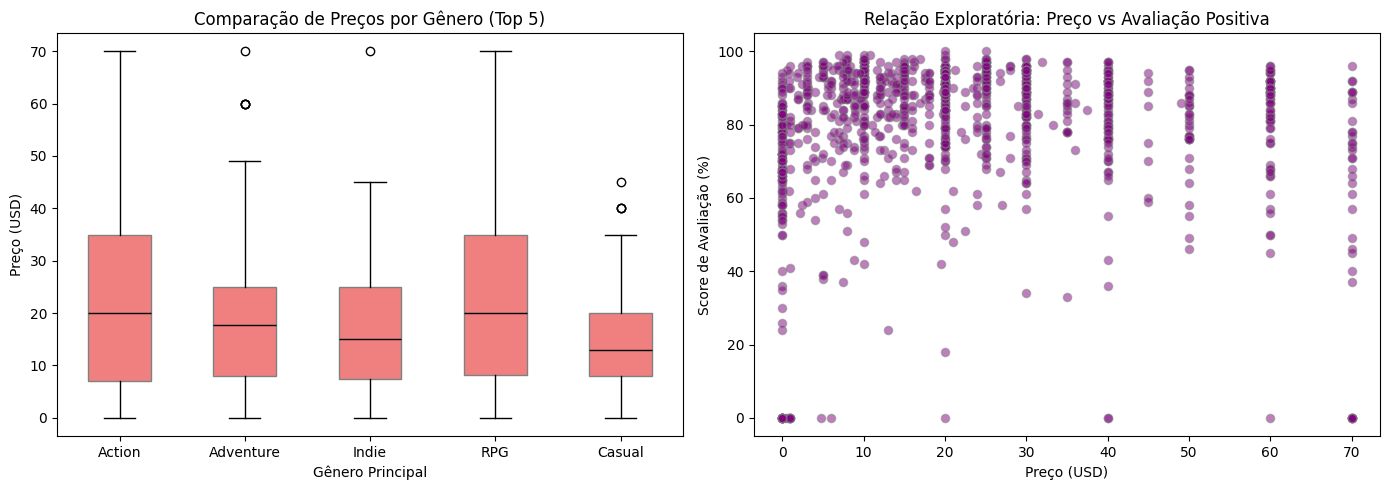

,count,mean,median,std,max
Primary_Genre,,,,,
Action,579,23.04,19.99,20.16,69.99
Adventure,102,18.68,17.79,14.93,69.99
Casual,63,15.65,12.99,11.33,44.99
Indie,73,16.95,14.99,12.62,69.99
RPG,71,22.78,19.99,17.64,69.99


In [14]:
#Gêneros principais
top_5_generos = df['Primary_Genre'].value_counts().head(5).index
df_top5 = df[df['Primary_Genre'].isin(top_5_generos)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#Gráfico 1(boxplot comparativo preparando os dados em lista para o matplotlib)
dados_boxplot = [df_top5[df_top5['Primary_Genre'] == genero]['Price_USD'] for genero in top_5_generos]

axes[0].boxplot(dados_boxplot, labels=top_5_generos, patch_artist=True, boxprops=dict(facecolor='lightcoral', color='grey'), medianprops=dict(color='black'))
axes[0].set_title('Comparação de Preços por Gênero (Top 5)')
axes[0].set_xlabel('Gênero Principal')
axes[0].set_ylabel('Preço (USD)')

#Gráfico 2 (dispersão de preçoo x avaliação)
axes[1].scatter(df['Price_USD'], df['Review_Score_Pct'], alpha=0.5, color='purple', edgecolor='grey')
axes[1].set_title('Relação Exploratória: Preço vs Avaliação Positiva')
axes[1].set_xlabel('Preço (USD)')
axes[1].set_ylabel('Score de Avaliação (%)')

plt.tight_layout()
plt.show()

#Tabela estatística dos gêneros
resumo_grupos = df_top5.groupby('Primary_Genre')['Price_USD'].agg(['count', 'mean', 'median', 'std', 'max']).round(2)
display(resumo_grupos)

#Acima dos gráficos há uma mensagem que não consegui identificar direito o que é. IAs me recomendaram trocar uma linha mas preferi manter para evitar problemas

**Interpretação:**
* **Comparação entre grupos:** O boxplot comparativo revela que categorias como 'Action' e 'RPG' possuem muita variabilidade nos preços (caixas longas, maior desvio padrão), enquanto gêneros como 'Casual' e 'Indie' têm medianas bem inferiores e menor variabilidade. Geralmente estes jogos têm um preço bem mais baixo por não serem de estúdios muito grandes, ocasionando nos apontamaentos que observamos nos gráficos.
* **Relação de variáveis:** O gráfico de dispersão deixa a entender que preço e nota não têm muita correlação. Existem jogos grátis ou baratos com 100% de aprovação e também com 0%. No entanto, nota-se na parte inferior direita do gráfico que jogos nas faixas de preços maiores (40USD+) apresentam certa resistência a receberem avaliações terríveis.

## 2.7 Conclusões

Respondendo às perguntas iniciais propostas:

1. **Distribuição doss preços:** O mercado tem preços muito variados, mas concentra-se em faixas acessíveis. Metade dos jogos da plataforma custa até 19,79USD, enquanto valores mais altos (60USD - 70USD) são outliers.
2. **Impressão do público:** É muito positiva num geral para qualquer tipo de jogo. A assimetria à esquerda do gráfico de avaliações mostra que a maioria dos jogos possuem avaliação superior a 75%, ficando as notas baixas contidas em um pequeno grupo na cauda inferior.
3. **Diferenças por gênero:** Gêneros como 'Action' e 'RPG' têm cobranças maiores, com forte dispersão de preços, e jogos tipo 'Casual' e 'Indie' ficam num segmento de preços mais equilibrados e baratos.
4. **Preço vs Avaliação:** Não existe indicação clara de relação ("cobrar mais caro resulta em nota maior ou vice-versa"). Contudo, títulos muito caros tendem a ter uma avaliação básica mínima razoável, muito possivelmente devido à disparidade de orçamentos de produção (não temos acesso a esta variável, é um insight pessoal meu por entendimento do meio) entre pequenos e grandes estúdios.

**Limitações:**

- O dataset é fixo em 1.000 jogos e com foco nos últimos anos, além de não incluir variáveis temporais como mudança de avaliações. Exemplo: um grande jogo lançado recentemente (Cyberpunk 2077) foi lançado com uma qualidade muito inferior à expectativa criada em torno do produto. Isso ocasionou em uma enxurrada de avaliações ruins no primeiro semestre após a data de disponibilização. Após isso, os desenvolvedores trabalharam para corrigir a maioria dos problemas e o jogo teve um aumento muito grande em avaliações positivas, mudando o cenário.